# Iris dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

In [15]:
iris = pd.read_csv("../data/iris.csv")
iris.info()
X = iris.drop("Species", axis=1)
y = iris["Species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## Preprocessing

In [16]:
num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.select_dtypes(include=["float64"]).columns),
])

## Hyperparameter Tuning and Cost Complexity Pruning

In [17]:
tree = make_pipeline(
    preprocessing,
    DecisionTreeClassifier(criterion="gini")
)


tree_grid = GridSearchCV(
    tree,
    {"decisiontreeclassifier__max_depth": range(10, 15)},
    refit=True,
    cv=5,
    scoring="accuracy"
)

tree_grid.fit(X_train, y_train)
reg = tree_grid.best_estimator_


X_train_prep = reg[:-1].transform(X_train)
ccp_path = reg[-1].cost_complexity_pruning_path(X_train_prep, y_train) # compute alphas

grid = GridSearchCV(
    reg,
    {"decisiontreeclassifier__ccp_alpha": ccp_path.ccp_alphas},
    refit=True,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train , y_train)


/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
  File "/home/rosario/miniconda3/envs/data-analytics/lib/python3.10/site-packages/sklearn/utils/_p

,estimator,Pipeline(step...x_depth=14))])
,param_grid,"{'decisiontreeclassifier__ccp_alpha': array([0. ..., 0.33340278])}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...)]"


## Evaluation

Accuracy: 1.0

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Confusion matrix:



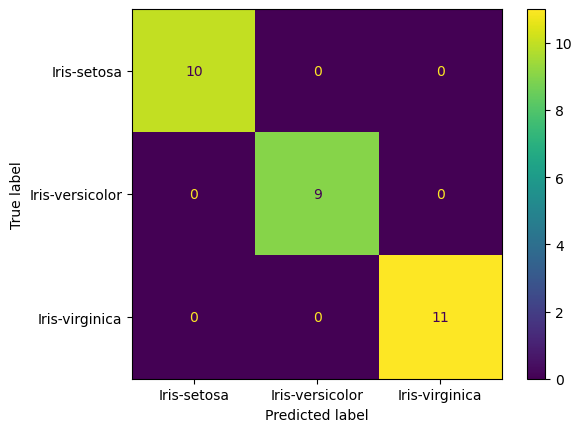

In [20]:
model = grid.best_estimator_
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print()
print("Classification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print()
